Importing plotly failed. Interactive plots will not work.
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/886711669.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/886711669.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
16:02:59 - cmdstanpy - INFO - Chain [1] start processing
16:02:59 - cmdstanpy - INFO - Chain [1] done processing
16:02:59 - cmdstanpy - INFO - Chain [1] start processing
16:02:59 - cmdstanpy - INFO - Chain [1] done processing
16:02:59 - cmdstanpy - INFO - Chain [1] start processing
16:02:59 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – OFF‑shore TEST METRICS ===
Monthly  MSE=117,781,694,146.01  RMSE=343,193.38  MAE=256,166.91  R²=0.2270  MAPE=13.86%
Weekly   MSE=741,619,694,577.55  RMSE=861,173.44  MAE=697,501.44  R²=-0.0672  MAPE=66.06%
Daily    MSE=1,569,036,042,582.33  RMSE=1,252,611.69  MAE=1,142,380.22  R²=-0.1521  MAPE=355.97%


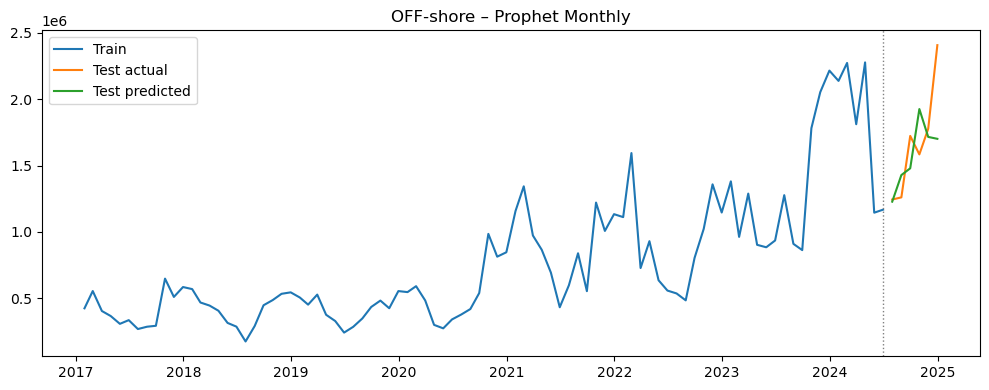

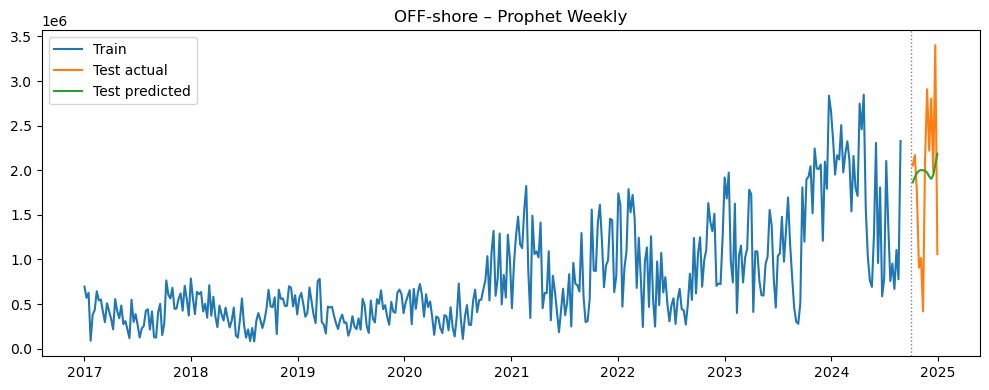

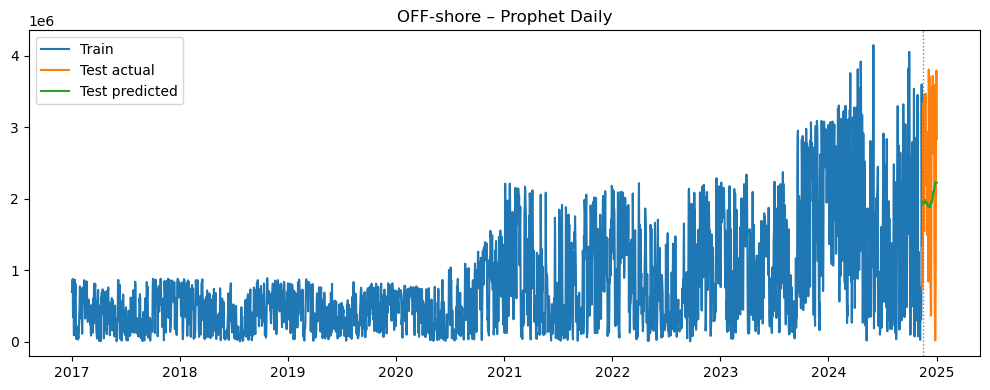

In [ ]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "data/final_offshore_data_2017_2025.csv" 
SITE      = "OFF‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/142345980.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/142345980.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
16:03:00 - cmdstanpy - INFO - Chain [1] start processing
16:03:00 - cmdstanpy - INFO - Chain [1] done processing
16:03:00 - cmdstanpy - INFO - Chain [1] start processing
16:03:01 - cmdstanpy - INFO - Chain [1] done processing
16:03:01 - cmdstanpy - INFO - Chain [1] start processing
16:03:01 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – ON‑shore TEST METRICS ===
Monthly  MSE=146,740,968,702.83  RMSE=383,067.84  MAE=333,167.48  R²=0.0551  MAPE=18.70%
Weekly   MSE=967,559,384,228.97  RMSE=983,645.96  MAE=779,669.10  R²=-0.1314  MAPE=75.28%
Daily    MSE=1,847,613,681,970.22  RMSE=1,359,269.54  MAE=1,233,757.13  R²=-0.0842  MAPE=381.61%


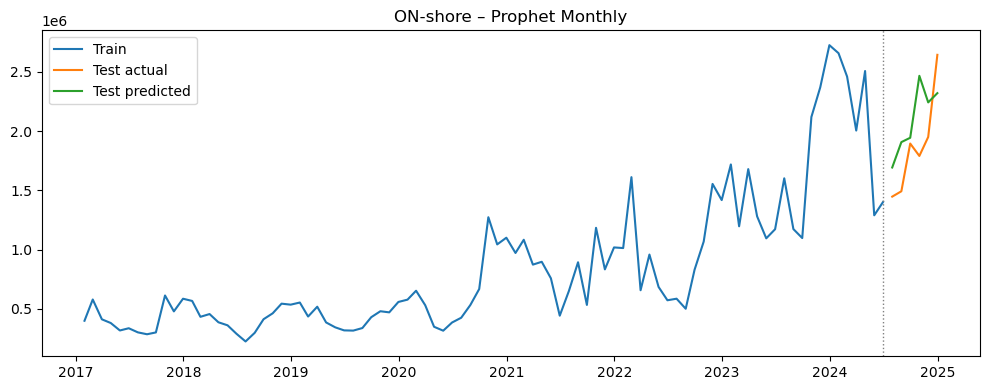

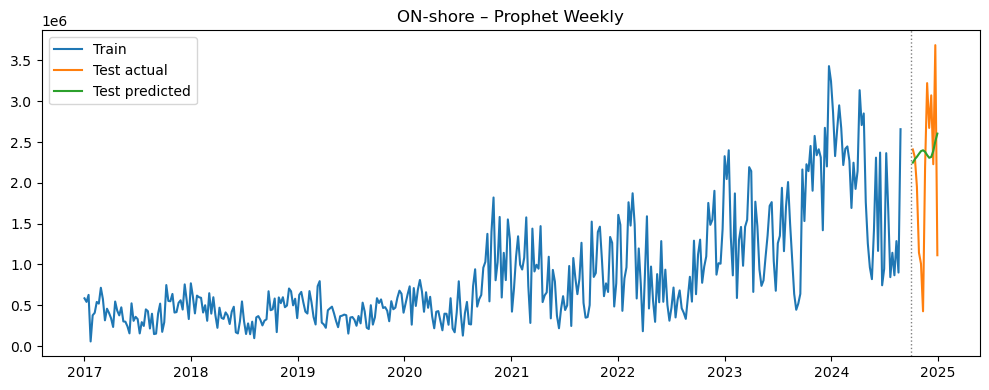

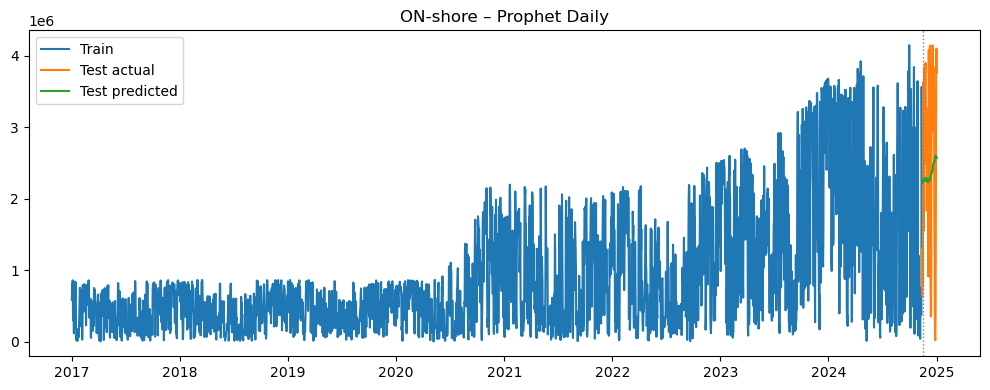

In [ ]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT ФУНКЦИЯ -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================



=== Onshore ===


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/2272778826.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/2272778826.py:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
16:52:50 - cmdstanpy - INFO - Chain [1] start processing
16:52:51 - cmdstanpy - INFO - Chain [1] done processing
16:52:51 - cmdstanpy - INFO - Chain [1] start processing
16:52:51 - cmdstanpy - INFO - Chain [1] done processing
16:52:51 - cmdstanpy - INFO - Chain [1] start processing
16:52:51 - cmdstanpy - INFO - Chain [1] done processing


Monthly  MSE=146,740,968,702.83  RMSE=383,067.84  MAE=333,167.48  R²=0.0551  MAPE=18.70%
Weekly   MSE=967,559,384,228.97  RMSE=983,645.96  MAE=779,669.10  R²=-0.1314  MAPE=75.28%
Daily    MSE=1,847,613,681,970.22  RMSE=1,359,269.54  MAE=1,233,757.13  R²=-0.0842  MAPE=381.61%


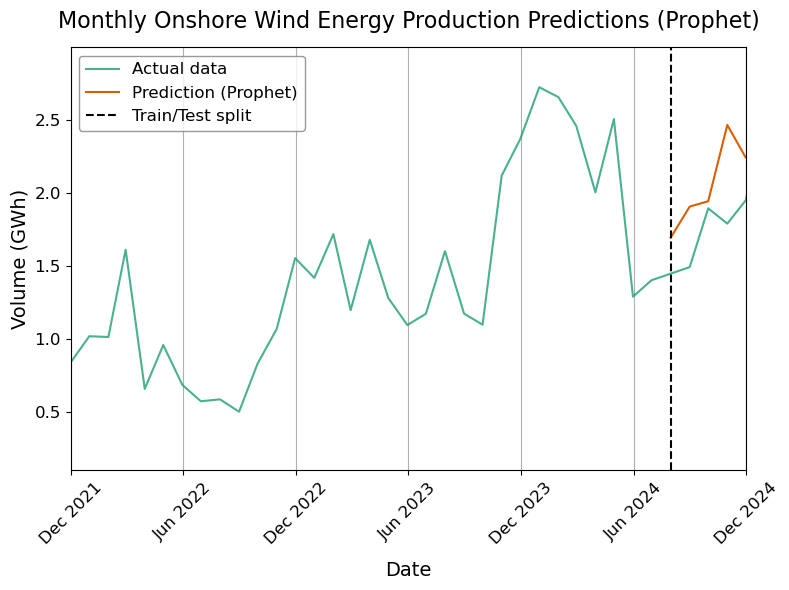

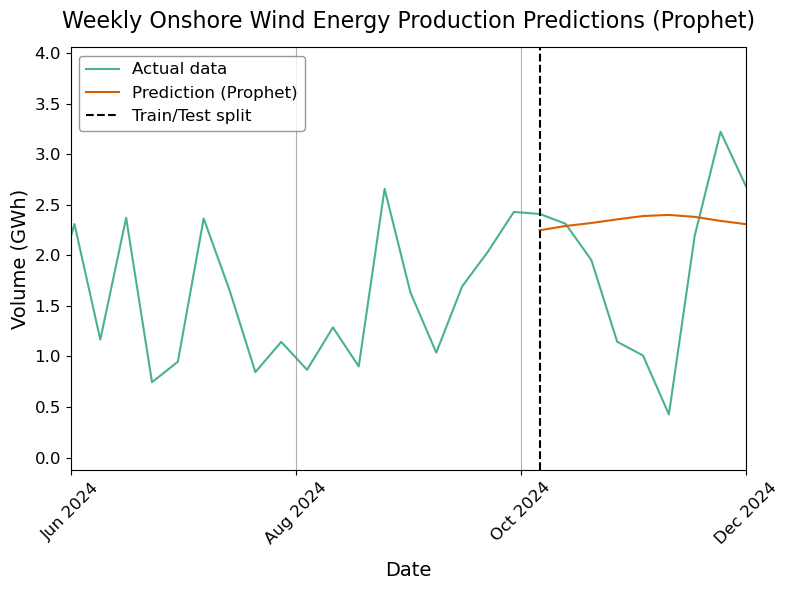

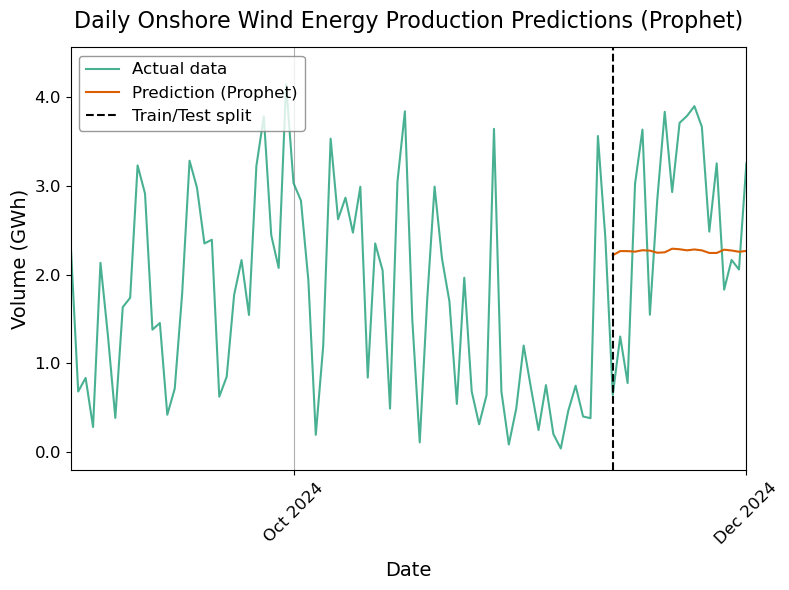


=== Offshore ===


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/2272778826.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_31037/2272778826.py:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
16:52:53 - cmdstanpy - INFO - Chain [1] start processing
16:52:53 - cmdstanpy - INFO - Chain [1] done processing
16:52:53 - cmdstanpy - INFO - Chain [1] start processing
16:52:53 - cmdstanpy - INFO - Chain [1] done processing
16:52:53 - cmdstanpy - INFO - Chain [1] start processing
16:52:53 - cmdstanpy - INFO - Chain [1] done processing


Monthly  MSE=117,781,694,146.01  RMSE=343,193.38  MAE=256,166.91  R²=0.2270  MAPE=13.86%
Weekly   MSE=741,619,694,577.55  RMSE=861,173.44  MAE=697,501.44  R²=-0.0672  MAPE=66.06%
Daily    MSE=1,569,036,042,582.33  RMSE=1,252,611.69  MAE=1,142,380.22  R²=-0.1521  MAPE=355.97%


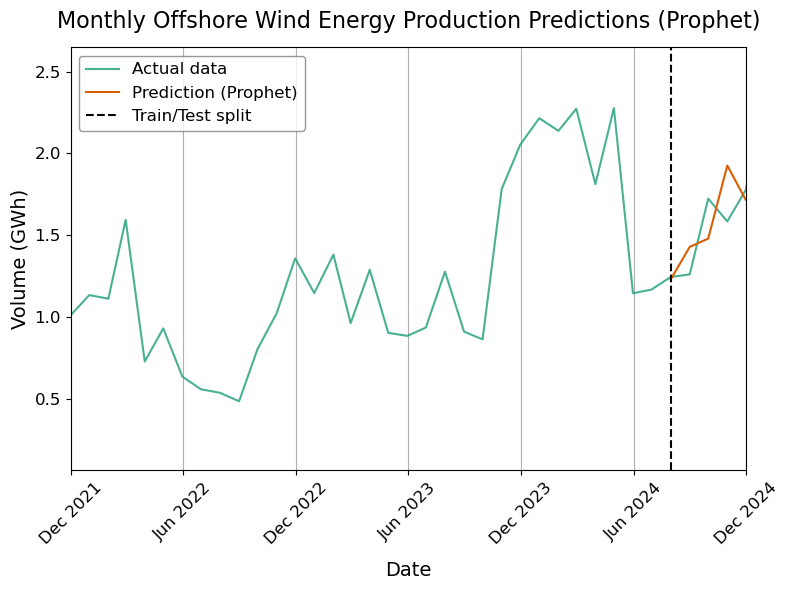

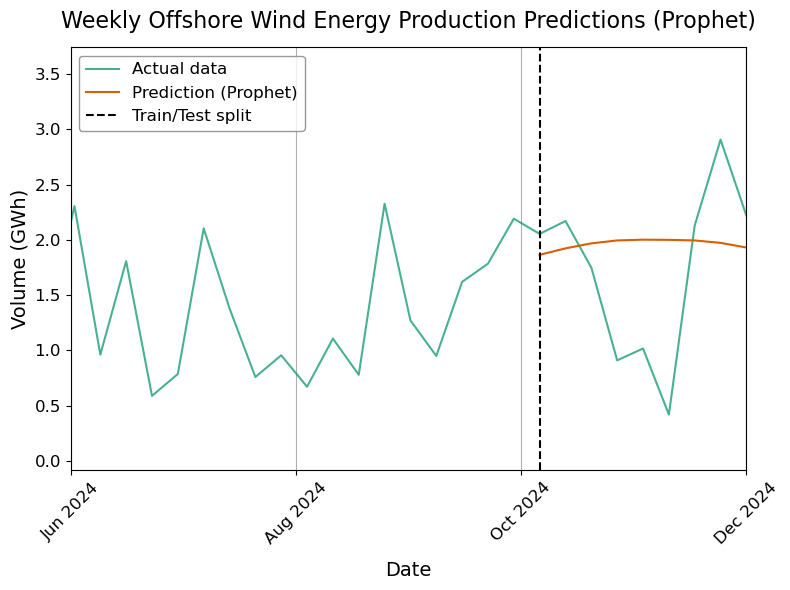

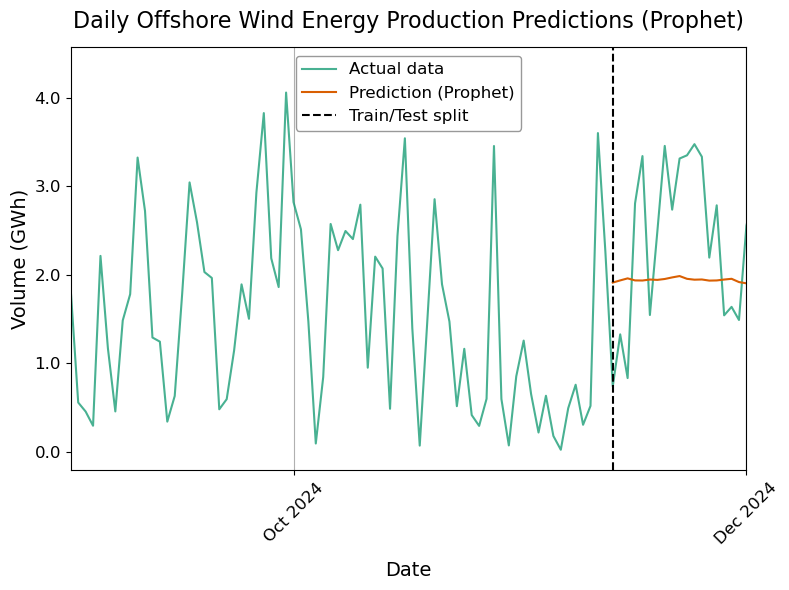

In [ ]:


# ------------------------------------------------------------
# Configuration (file paths) ---------------------------------
# ------------------------------------------------------------
CFG = [
    {
        "path": "data/final_onshore_data_2017_2025.csv",
        "site": "Onshore",
    },
    {
        "path": "data/final_offshore_data_2017_2025.csv",
        "site": "Offshore",
    },
]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Utility functions ------------------------------------------
# ------------------------------------------------------------

def load_and_prepare(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[["date", "hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
    df["hour"] = df["hour_str"].astype(int) - 1
    df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
    df["y"] = df["volume"]
    return df.sort_values("ds").set_index("ds")

def aggregate(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

def split(df: pd.DataFrame, train_end, val_start, val_end, test_start, test_end):
    tr = df[df.ds <= train_end].copy()
    val = df[(df.ds >= val_start) & (df.ds < val_end)].copy()
    te = df[(df.ds >= test_start) & (df.ds < test_end)].copy()
    return tr, val, te, pd.to_datetime(test_start)

def mape(a, f):
    return np.mean(np.abs((a - f) / (a + 1e-6))) * 100

def evaluate(model: Prophet, test_df: pd.DataFrame):
    fc = model.predict(test_df[["ds"]])[ ["ds", "yhat"] ]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse = mean_squared_error(y, yhat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, yhat)
    r2 = r2_score(y, yhat)
    return mse, rmse, mae, r2, mape(y, yhat)

# ------------------------------------------------------------
# Plotting helpers -------------------------------------------
# ------------------------------------------------------------

def _millions(x, pos):
    return f"{x * 1e-6:.1f}"

def styled_plot(full_df: pd.DataFrame,
                fc_df: pd.DataFrame,
                *,
                freq: str,
                title: str,
                xlim_start: str,
                xlim_end: str,
                site: str):
    plt.figure(figsize=(8, 6))
    plt.plot(full_df["ds"], full_df["y"], label="Actual data", color="#1b9e77", alpha=0.8)
    plt.plot(fc_df["ds"], fc_df["yhat"], label="Prediction (Prophet)", color="#d95f02")
    split_date = fc_df["ds"].min()
    plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test split')

    plt.title(title, pad=14, fontsize=16)
    plt.xlabel("Date", labelpad=10, fontsize=14)
    plt.ylabel("Volume (GWh)", fontsize=14)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(_millions))
    ax.grid(axis="x")
    ax.tick_params(axis="both", labelsize=12)
    plt.xticks(rotation=45)

    if freq == "Monthly":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    elif freq == "Weekly":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.xlim(pd.to_datetime(xlim_start), pd.to_datetime(xlim_end))
    ymax = max(full_df["y"].max(), fc_df["yhat"].max()) * 1.1
    plt.ylim(top=ymax)

    plt.legend(loc="best", fontsize=12, frameon=True,
               facecolor="white", edgecolor="grey", fancybox=True, framealpha=0.8)
    plt.tight_layout()

    filename = f"{PLOT_DIR}/{site.lower().replace('-', '')}_{freq.lower()[:3]}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# End-to-end pipeline per site ------------------------------
# ------------------------------------------------------------

def run_site(cfg_site):
    site = cfg_site["site"]
    print(f"\n=== {site} ===")

    raw = load_and_prepare(cfg_site["path"])
    df_M = aggregate(raw, "M")
    df_W = aggregate(raw, "W")
    df_D = aggregate(raw, "D")

    m_tr, m_val, m_te, m_split = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01", "2024-07-01", "2025-01-01")
    w_tr, w_val, w_te, w_split = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01", "2024-10-01", "2025-01-01")
    d_tr, d_val, d_te, d_split = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13", "2024-11-13", "2025-01-12")

    model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds", "y"]])
    model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds", "y"]])
    model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds", "y"]])

    metrics_M = evaluate(model_M, m_te)
    metrics_W = evaluate(model_W, w_te)
    metrics_D = evaluate(model_D, d_te)

    for lbl, metrics in zip(["Monthly", "Weekly", "Daily"], [metrics_M, metrics_W, metrics_D]):
        mse, rmse, mae, r2, mape_ = metrics
        print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape_:,.2f}%")

    full_M = pd.concat([m_tr, m_val, m_te]).sort_values("ds")
    full_W = pd.concat([w_tr, w_val, w_te]).sort_values("ds")
    full_D = pd.concat([d_tr, d_val, d_te]).sort_values("ds")

    fc_M = model_M.predict(m_te[["ds"]])[ ["ds", "yhat"] ]
    fc_W = model_W.predict(w_te[["ds"]])[ ["ds", "yhat"] ]
    fc_D = model_D.predict(d_te[["ds"]])[ ["ds", "yhat"] ]

    styled_plot(full_M, fc_M,
                freq="Monthly",
                title=f"Monthly {site} Wind Energy Production Predictions (Prophet)",
                xlim_start="2021-12", xlim_end="2024-12",
                site=site)

    styled_plot(full_W, fc_W,
                freq="Weekly",
                title=f"Weekly {site} Wind Energy Production Predictions (Prophet)",
                xlim_start="2024-06", xlim_end="2024-12",
                site=site)

    styled_plot(full_D, fc_D,
                freq="Daily",
                title=f"Daily {site} Wind Energy Production Predictions (Prophet)",
                xlim_start="2024-09", xlim_end="2024-12",
                site=site)

# ------------------------------------------------------------
# Main entry point -------------------------------------------
# ------------------------------------------------------------

if __name__ == "__main__":
    for cfg_site in CFG:
        run_site(cfg_site)